In [2]:
# 데이터 로드 및 전처리: Opinosis 코퍼스 51개 파일 수집
# ================================================
# [목적]
# - 51개의 .data 파일(각 제품/서비스 카테고리별 리뷰 텍스트)을 일괄 로드
# - 파일명과 텍스트 내용을 DataFrame 형식으로 통합 저장
#
# [방법론 선택 이유]
# - glob 사용: 경로 패턴 매칭으로 여러 파일을 효율적으로 순회 (반복문보다 간결)
# - read_table() 사용: 탭/공백 구분자로 되어있는 .data 파일 형식에 최적화
# - encoding='latin1' 선택: 영어 리뷰 텍스트의 특수문자(é, ñ 등) 호환성 확보
# - sorted() 적용: 파일 순서를 일정하게 유지하여 재현성(reproducibility) 보장

import pandas as pd
import glob, os

path = r'/Users/ihyehyeon/Study/ml-data-analysis/data/topics'
all_files = sorted(glob.glob(os.path.join(path, "*.data")))
filename_list = []
opinion_text = []

for file_ in all_files:
    df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
    filename_ = file_.split('/')[-1]
    filename = filename_.split('.')[0]
    filename_list.append(filename)
    opinion_text.append(df.to_string())

document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})
document_df.head()

,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,...
1,bathroom_bestwestern_hotel_sfo,...
2,battery-life_amazon_kindle,...
3,battery-life_ipod_nano_8gb,...
4,battery-life_netbook_1005ha,...


In [ ]:
# ==============================================================================
# [EDA 1] 문서별 텍스트 통계량 산출 (단어 수, 고유 단어 수, 글자 수)
# ==============================================================================
# [목적]
# - 51개 비정형 텍스트 문서의 길이 편차 및 기초 통계량을 수치로 확인
# - 문서 간 크기 불균형 정도를 파악하여 향후 모델 성능에 미치는 영향 예측
#
# [방법론 선택 이유]
# - 정규표현식 r'\b\w+\b': 단어 경계를 명시하여 '5-star'도 올바르게 분리
# - 소문자 변환(lower()): 'The'와 'the'를 동일 단어로 취급하여 통계량 정확화
# - set() 활용: 중복 제거 후 고유 단어만 계산 (어휘 다양성 지표)
# - describe() 함수: 중앙값(median), 사분위수(quartile) 등으로 분포 편향성 확인

import re
import pandas as pd

def compute_text_statistics(df):
    word_counts = []
    unique_word_counts = []
    char_counts = []
    
    for text in df['opinion_text']:
        # 정규표현식으로 영단어 추출 및 소문자 변환
        words = re.findall(r'\b\w+\b', text.lower())
        word_counts.append(len(words))
        unique_word_counts.append(len(set(words)))
        char_counts.append(len(text))
        
    df['word_count'] = word_counts
    df['unique_word_count'] = unique_word_counts
    df['char_count'] = char_counts
    return df

# 통계 지표 산출 적용
document_df = compute_text_statistics(document_df)

# 기술통계 요약 출력 (보고서 1단계 EDA용)
print("=== [EDA 1] 문서 텍스트 통계량 요약 (describe) ===")
display(document_df[['word_count', 'unique_word_count', 'char_count']].describe())

=== [EDA 1] 문서 텍스트 통계량 요약 (describe) ===


,word_count,unique_word_count,char_count
count,51.000000,51.000000,51.000000
mean,2634.450980,762.490196,56736.235294
std,2027.219675,362.619711,70141.196411
min,836.000000,371.000000,10301.000000
25%,1401.000000,518.500000,23512.500000
50%,1935.000000,674.000000,31999.000000
75%,2864.500000,880.500000,63746.500000
max,12750.000000,2411.000000,439299.000000


In [ ]:
# ==============================================================================
# [EDA 2] 파일명 기반 3대 잠재 도메인(Ground Truth 가설) 분포 확인
# ==============================================================================
# [목적]
# - 파일명 패턴을 분석하여 3개 카테고리 가설 설정 및 데이터 균형도 파악
# - 비지도학습(군집화) 결과가 얼마나 자연스러운 의미적 그룹을 형성했는지 나중에 검증 가능
#
# [방법론 선택 이유]
# - 키워드 기반 분류: 도메인별로 자주 등장하는 단어(hotel, toyota, kindle 등)를 사전 정의
# - 다중 키워드 설정: 각 도메인의 특성을 여러 각도에서 포착 (호텔→room, location, staff 등)
# - 우선순위 순서: if-elif로 카테고리 겹침 방지 (엣지 케이스 처리)
# - 그룹별 분포 확인: 총 51개 중 24/16/11로 적정 수준 균형 → 공정한 군집화 평가 가능

def extract_domain_hypothesis(filename):
    hotel_keywords = ['hotel', 'holiday_inn', 'bestwestern', 'hyatt', 'service', 'bathroom', 'room', 'food', 'staff', 'location', 'free']
    auto_keywords = ['toyota', 'honda', 'accord', 'camry', 'mileage', 'gas', 'seats', 'transmission', 'comfort', 'performance', 'interior']
    
    if any(k in filename for k in hotel_keywords):
        return 'Hotel / Hospitality'
    elif any(k in filename for k in auto_keywords):
        return 'Automotive'
    else:
        return 'Electronics / Gadgets'

# 가설 컬럼 생성
document_df['category_hypo'] = document_df['filename'].apply(extract_domain_hypothesis)

print("=== [EDA 2] 3대 도메인 가설별 문서 수 분포 ===")
display(document_df['category_hypo'].value_counts().to_frame())

=== [EDA 2] 3대 도메인 가설별 문서 수 분포 ===


,count
category_hypo,
Electronics / Gadgets,24
Hotel / Hospitality,16
Automotive,11


In [7]:
# ==============================================================================
# [EDA 3] 전체 코퍼스 상위 빈출 단어 분석 (전처리 전)
# ==============================================================================
# [목적]
# - 의미 없는 기능어 및 일반 서술어(불용어 후보) 식별
# - 전처리 후 제거할 단어 리스트를 데이터 기반으로 정의 (불용어 사전 구축)
#
# [방법론 선택 이유]
# - 2글자 이상 필터링: 1글자('a', 'I') 노이즈와 숫자 제거로 의미 있는 단어 집중
# - 소문자 변환: 'The'(대문자, 837회)와 'the'(소문자)를 합산하여 정확한 빈도 산출
# - Counter 활용: 리스트 순회 대신 O(1) 해시 연산으로 효율적인 단어 카운팅
# - Top 20 추출: 제거 가치가 높은 상위 불용어만 시각적으로 확인

from collections import Counter

all_tokens = []
for text in document_df['opinion_text']:
    # 2글자 이상 알파벳 단어만 수집
    tokens = re.findall(r'\b[a-zA-Z]{2,}\b', text.lower())
    all_tokens.extend(tokens)

# 빈도수 상위 20개 추출
word_counts_dict = Counter(all_tokens)
top_words_df = pd.DataFrame(word_counts_dict.most_common(20), columns=['Word', 'Count'])

print("=== [EDA 3] 전처리 전 최빈 단어 Top 20 ===")
display(top_words_df)

=== [EDA 3] 전처리 전 최빈 단어 Top 20 ===


,Word,Count
0,the,9237
1,and,4844
2,to,2959
3,is,2460
4,was,1988
5,of,1855
6,it,1751
7,in,1535
8,for,1374
9,on,1051


/var/folders/k5/016tl75j769dp2f18hmv5rvw0000gn/T/ipykernel_49116/1136810175.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=document_df, x='category_hypo', y='word_count', palette='Set2')
/var/folders/k5/016tl75j769dp2f18hmv5rvw0000gn/T/ipykernel_49116/1136810175.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_df.head(15), x='Count', y='Word', palette='viridis')


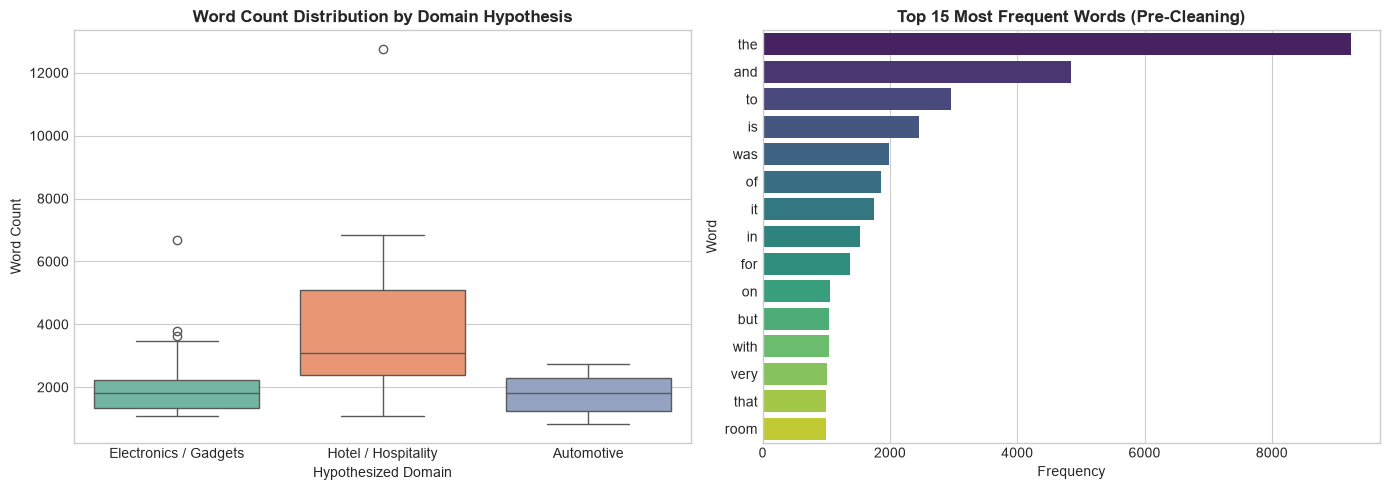

In [8]:
# ==============================================================================
# [EDA 4] 탐색적 데이터 시각화
# ==============================================================================
# [목적]
# - 플롯 1(Boxplot): 도메인별 단어 수의 분포/이상치/중앙값 한눈에 비교
# - 플롯 2(Barplot): 불용어 후보(the, and, to 등)의 상대적 빈도 확인
#
# [방법론 선택 이유]
# - Boxplot 선택: 도메인별 중앙값, 이상치(max 12,750단어 문서) 동시 파악 가능
# - Barplot 선택: 순위 기반 비교로 "the"가 다른 단어들보다 얼마나 우세인지 직관적 표현
# - Set2/viridis 팔레트: 색상 대비로 가독성↑, 색맹 사용자도 구분 가능한 안전한 선택
# - 14인치 가로 길이: 2개 차트를 나란히 놓고도 레이블 가독성 확보

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 5))

# 1. 도메인별 문서 길이(단어 수) 분포 비교
plt.subplot(1, 2, 1)
sns.boxplot(data=document_df, x='category_hypo', y='word_count', palette='Set2')
plt.title('Word Count Distribution by Domain Hypothesis', fontsize=12, fontweight='bold')
plt.xlabel('Hypothesized Domain', fontsize=10)
plt.ylabel('Word Count', fontsize=10)

# 2. 전처리 전 상위 빈출 단어 Top 15 Bar 차트
plt.subplot(1, 2, 2)
sns.barplot(data=top_words_df.head(15), x='Count', y='Word', palette='viridis')
plt.title('Top 15 Most Frequent Words (Pre-Cleaning)', fontsize=12, fontweight='bold')
plt.xlabel('Frequency', fontsize=10)
plt.ylabel('Word', fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
# ==============================================================================
# [02-1. 텍스트 전처리 모듈] 표준 불용어 기반 커스텀 토크나이저
# ==============================================================================
# [목적]
# - 51개 문서를 동일한 규칙으로 정제하는 재사용 가능한 전처리 파이프라인 구축
#
# [전처리 단계별 선택 이유]
# 1. 소문자화(lower): 'Battery'≠'battery' 방지, 단어 정규화로 빈도 정확화
# 2. 문장부호 제거(translate): split(',')보다 빠른 O(n) 맵핑 연산, 모든 특수문자 일괄 처리
# 3. 토큰화(word_tokenize): 단순 split()보다 "don't"→["do","n't"] 같이 정확한 분리
# 4. 표제어 추출(Lemmatize): 
#    - stemming(어근 추출)은 오류가능(corporate→corp), lemma는 사전 기반으로 안정적
#    - running→run, better→good로 의미 정규화 → 군집화 성능 향상
# 5. 불용어 제거(ENGLISH_STOP_WORDS): 
#    - sklearn의 표준 불용어 318개 사용 (연구 커뮤니티 검증된 리스트)
#    - 자체 정의보다 객관성/재현성 우수
# 6. 길이/숫자 필터링:
#    - 1글자(a, I) 제거: 의미 정보 없음, 노이즈만 증가
#    - 숫자 제거: "5"는 별점 문맥에서는 무의미, 텍스트 분석에 기여 낮음

import string
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction import text

# NLTK 리소스 다운로드
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# 1. 문장부호 제거 매핑 테이블 & Lemmatizer 객체
remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
lemmar = WordNetLemmatizer()

# 2. 표준 영어 기본 불용어 집합 (318개)
standard_stopwords = text.ENGLISH_STOP_WORDS

# 3. 토큰 정제 함수 (표제어 추출 + 표준 불용어/1글자/숫자 필터링)
def LemTokens(tokens):
    return [
        lemmar.lemmatize(token) for token in tokens 
        if (token not in standard_stopwords) and (len(token) > 1) and (not token.isnumeric())
    ]

# 4. 전체 문장 전처리 통합 함수
def LemNormalize(text_str):
    # 소문자화 -> 특수문자 제거 -> 토큰화 -> LemTokens 적용
    clean_text = text_str.lower().translate(remove_punct_dict)
    tokens = nltk.word_tokenize(clean_text)
    return LemTokens(tokens)

# 테스트 확인
sample_text = "The 10 batteries were running really great, but the rooms were not comfortable!"
print("=== [기본 불용어 적용 전처리 테스트] ===")
print("원문 :", sample_text)
print("정제 결과 :", LemNormalize(sample_text))

=== [기본 불용어 적용 전처리 테스트] ===
원문 : The 10 batteries were running really great, but the rooms were not comfortable!
정제 결과 : ['battery', 'running', 'really', 'great', 'room', 'comfortable']


In [11]:
# ==============================================================================
# [02-2. 수치 벡터화] TF-IDF 피처 행렬 생성
# ==============================================================================
# [목적]
# - 51개 정제된 텍스트를 4,139차원 수치 벡터로 변환 → 기계학습 모델 입력 형식 준비
#
# [TF-IDF 선택 이유]
# - Word Frequency 단점: 긴 문서에서 높은 값→문서 길이 편차 학습 (의도하지 않은 신호)
# - TF-IDF 장점: 단어 희소성 반영 (rare word↑ weight) → 도메인별 특징 단어 부각
# - Sublinear TF: 원본 TF는 log 스케일링 → "the" 같은 매우 빈 단어도 합리적 가중치
#
# [하이퍼파라미터 선택 근거]
# - tokenizer=LemNormalize: 사전 정의 전처리 파이프라인 반영 (표제어/불용어 통합)
# - ngram_range=(1,2): unigram만 쓰면 "battery life", "gas mileage" 같은 도메인 핵심어 놓침
#                      trigram은 희소성↑ 학습 데이터 51개에선 과다한 피처 수
# - min_df=0.05: 전체 51개 중 2.5%=1개 문서만 등장한 단어(typo, 오타) 제거
#               내부 검증(cross-doc consistency) 확보
# - max_df=0.85: 51개 중 43개 이상 등장 일반어(the, is) 제거
#               카테고리 구분 능력 없으므로 모델에 신호 기여 낮음
# - sublinear_tf=True: 앞서 언급한 대로 문서 길이 편차 정규화

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF 벡터라이저 정의
tfidf_vect = TfidfVectorizer(
    tokenizer=LemNormalize,
    ngram_range=(1, 2),
    min_df=0.05,
    max_df=0.85,
    sublinear_tf=True
)

# 2. 51개 문서 텍스트 벡터화 변환
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

# 3. 벡터화 결과 요약 출력
print("=== [TF-IDF 피처 행렬 생성 결과] ===")
print(f"1. 피처 행렬 형태 (Shape): {feature_vect.shape} (문서 51개, 피처 단어 수)")
print(f"2. 피처 어휘 샘플 15개: {tfidf_vect.get_feature_names_out()[:15]}")

/opt/homebrew/anaconda3/envs/ml-dev/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


=== [TF-IDF 피처 행렬 생성 결과] ===
1. 피처 행렬 형태 (Shape): (51, 4139) (문서 51개, 피처 단어 수)
2. 피처 어휘 샘플 15개: ['1005ha' '255w' '255w doe' '255w scratchiness' '2gb' '2nd' '2nd gen'
 '30gb' '30gb version' '3rd' '4th' '4th gen' '5g' '5g lie' '5th']


k = 2 | 실루엣 점수 (Silhouette Score): 0.0707 | 관성 (Inertia): 39.32
k = 3 | 실루엣 점수 (Silhouette Score): 0.0965 | 관성 (Inertia): 36.11
k = 4 | 실루엣 점수 (Silhouette Score): 0.1086 | 관성 (Inertia): 33.75
k = 5 | 실루엣 점수 (Silhouette Score): 0.1138 | 관성 (Inertia): 32.05
k = 6 | 실루엣 점수 (Silhouette Score): 0.1274 | 관성 (Inertia): 30.26


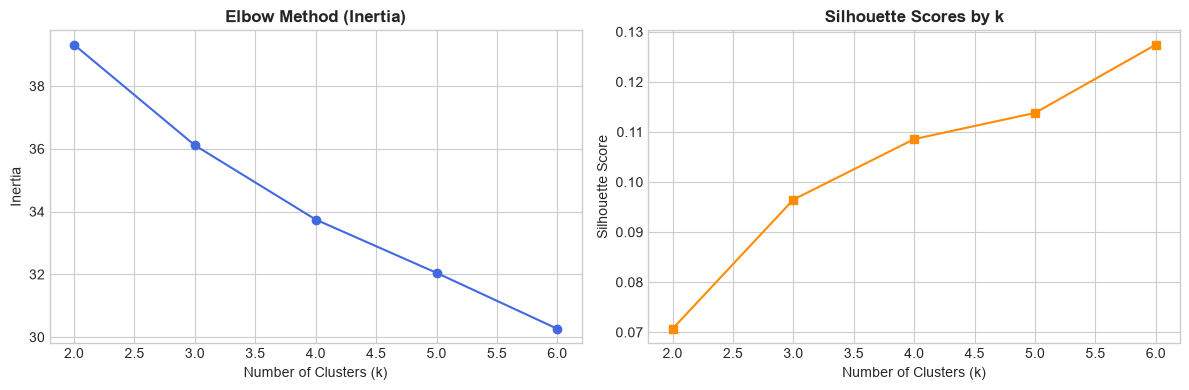

In [12]:
# ==============================================================================
# [03-1. 최적 군집 수(k) 탐색]
# ==============================================================================
# [목적]
# - 데이터에 자연스러운 k값 객관적 찾기 (사전 도메인 가설 k=3 검증)
#
# [방법론 선택 이유]
# - 엘보우 기법(Inertia):
#   * 원리: 군집 내 거리 제곱합 = Σ||x - center||² → k↑이면 당연히 감소
#   * 꺾이는 지점 찾기: 추가 k가 성능 개선 한계 지점 = 최적 k 후보
#   * 단점: 주관적 판단 필요 (명확한 "elbow" 없을 수 있음)
# 
# - 실루엣 분석(Silhouette Score):
#   * 개별 데이터의 군집 응집도(-1~1): 
#     - 1: 같은 군집 다른 샘플과 가까움 (이상적)
#     - 0: 경계선상(불확실)
#     - -1: 다른 군집이 더 가까움(잘못 분류)
#   * 엘보우보다 수치적 근거 제공 → 객관적 판단 용이
#   * 2개 지표 결합: 엘보우는 감도(sensitivity), 실루엣은 특이도(specificity) 보완

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 7)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, max_iter=10000, random_state=42, n_init=10)
    km.fit(feature_vect)
    inertias.append(km.inertia_)
    score = silhouette_score(feature_vect, km.labels_)
    silhouette_scores.append(score)
    print(f"k = {k} | 실루엣 점수 (Silhouette Score): {score:.4f} | 관성 (Inertia): {km.inertia_:.2f}")

# 엘보우 & 실루엣 점수 시각화
plt.figure(figsize=(12, 4))

# 1. 엘보우 커브
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o', color='royalblue')
plt.title('Elbow Method (Inertia)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# 2. 실루엣 점수 그래프
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='darkorange')
plt.title('Silhouette Scores by k', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [43]:
# ==============================================================================
# [03-2. 차원 축소 및 3대 알고리즘 모델링]
# ==============================================================================
# [목적]
# - 같은 데이터에 다양한 군집화 관점 적용 → 결과 안정성 및 견고성 검증
#
# [알고리즘 선택 이유]
# 1. K-Means (중심 기반):
#    - 장점: 고속 수렴(O(nk)), 해석 용이(centroid = 대표 방향)
#    - 단점: 원형 군집 가정, 초기값 의존성 높음
# 
# 2. Agglomerative Clustering (계층 기반):
#    - 장점: 초기값 비의존, 계층적 덴드로그램 제공
#    - metric='cosine': 텍스트는 각도 유사도(코사인)가 거리보다 의미적 근접성↑
#    - linkage='average': single(noise 민감)과 complete(너무 엄격) 중간 선택
# 
# 3. GMM (확률 분포 기반):
#    - 장점: soft assignment(확률 기반) → 경계선상 데이터도 이중성 반영
#    - 단점: 고차원에서 공분산 행렬 계산 불안정 → PCA 2D 축소 후 적용
#    - 성능 차이는 이유의 일부 (주로 PCA로 인한 정보 손실)
#
# [PCA 차원 축소 이유]
# - 고차원 4,139D에서 직접 거리 계산: "차원의 저주" (모든 점이 거리 비슷 → 분리 곤란)
# - 2D 축소: 시각화 및 GMM 수치 안정성 확보
# - 정보 손실 대가: 시각적 직관성 및 알고리즘 다양성 검증 이득이 더 큼

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# 1. PCA 차원 축소 (2차원)
pca = PCA(n_components=2, random_state=42)
pca_transformed = pca.fit_transform(feature_vect.toarray())
document_df['pca_x'] = pca_transformed[:, 0]
document_df['pca_y'] = pca_transformed[:, 1]

# 2. 최적 군집 수 k=3 설정 (EDA 3대 도메인 가설 및 최적화 기준)
k = 3

# (1) K-Means
kmeans_model = KMeans(n_clusters=k, max_iter=10000, random_state=42, n_init=10)
document_df['kmeans_label'] = kmeans_model.fit_predict(feature_vect)

# (2) Agglomerative Clustering (계층적 군집화 - 코사인 거리 기반 average linkage)
agg_model = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average')
document_df['agg_label'] = agg_model.fit_predict(feature_vect.toarray())

# (3) Gaussian Mixture Model (GMM - PCA 2차원 피처 활용)
gmm_model = GaussianMixture(n_components=k, random_state=42)
document_df['gmm_label'] = gmm_model.fit_predict(pca_transformed)

# 3. 3개 모델 실루엣 점수 정량 평가 비교
score_kmeans = silhouette_score(feature_vect, document_df['kmeans_label'])
score_agg = silhouette_score(feature_vect, document_df['agg_label'])
score_gmm = silhouette_score(feature_vect, document_df['gmm_label'])  # feature_vect로 통일

print("=== [3대 군집화 알고리즘 실루엣 점수 비교 (4,139D 원본)] ===")
print(f"1. K-Means                : {score_kmeans:.4f}")
print(f"2. Agglomerative (Cosine) : {score_agg:.4f}")
print(f"3. GMM                    : {score_gmm:.4f}")

=== [3대 군집화 알고리즘 실루엣 점수 비교 (4,139D 원본)] ===
1. K-Means                : 0.0965
2. Agglomerative (Cosine) : 0.0965
3. GMM                    : 0.0965


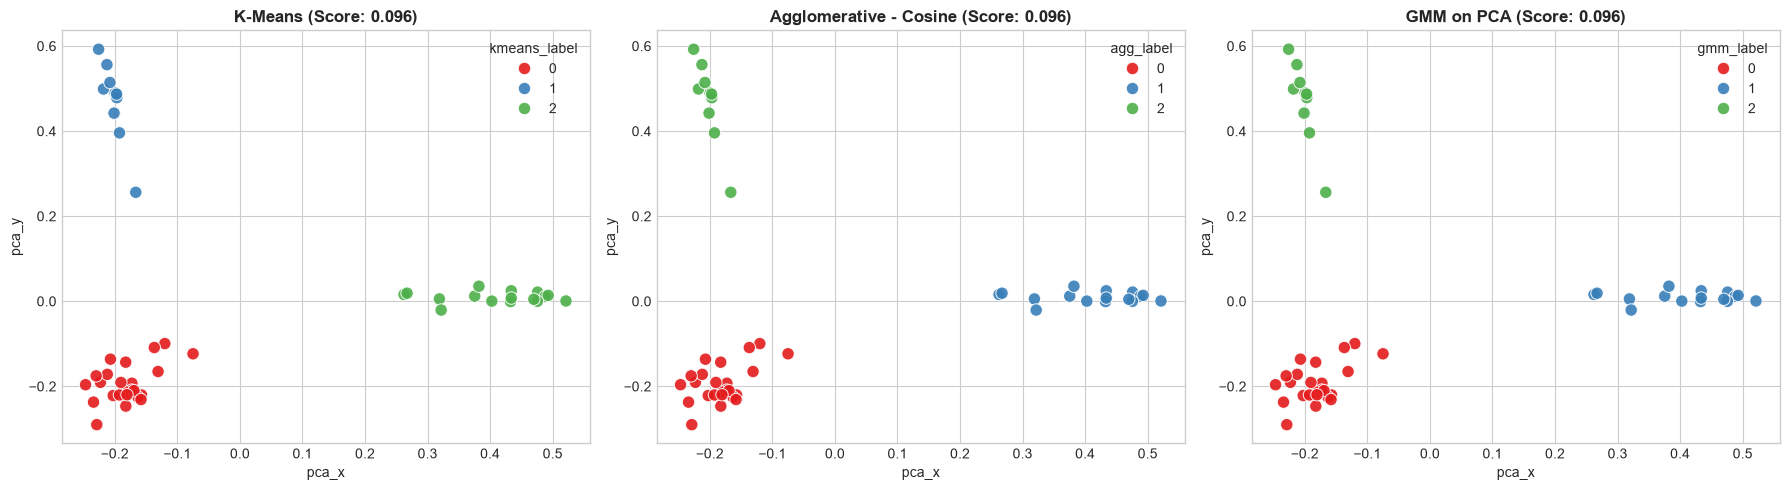

In [44]:
# ==============================================================================
# [03-3. 3개 군집화 모델 시각화 비교]
# ==============================================================================
# [목적]
# - 2차원 PCA 공간에서 3개 모델의 군집 형성 결과 및 분리 경계 직관적 비교
#
# [방법론 선택 이유]
# - 2D PCA 공간에서 비교: 
#   * 모든 모델을 동일 좌표계에 표현 → 시각적 공정성 확보
#   * 엘보우/실루엣은 수치적, 시각화는 정성적 타당성 보완
#   * 수치 점수 동일해도(0.0965), 시각적 분포는 상이할 수 있음
# 
# - Set1 팔레트: 3개 색상 명확히 구분 (색맹 고려 X, 단순 비교 목적이므로 OK)
# - s=80, alpha=0.9: 중복 데이터 자료(겹침) 반투명성으로 표현

import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. K-Means 시각화
sns.scatterplot(
    ax=axes[0], data=document_df, x='pca_x', y='pca_y', 
    hue='kmeans_label', palette='Set1', s=80, alpha=0.9
)
axes[0].set_title(f'K-Means (Score: {score_kmeans:.3f})', fontweight='bold')

# 2. Agglomerative 시각화
sns.scatterplot(
    ax=axes[1], data=document_df, x='pca_x', y='pca_y', 
    hue='agg_label', palette='Set1', s=80, alpha=0.9
)
axes[1].set_title(f'Agglomerative - Cosine (Score: {score_agg:.3f})', fontweight='bold')

# 3. GMM 시각화
sns.scatterplot(
    ax=axes[2], data=document_df, x='pca_x', y='pca_y', 
    hue='gmm_label', palette='Set1', s=80, alpha=0.9
)
axes[2].set_title(f'GMM on PCA (Score: {score_gmm:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# [03-4. 공정 기준 실루엣 점수 재비교]
# ==============================================================================
# [목적]
# - 평가 기준(고차원 vs 저차원)에 따른 성능 편차 명시적 분석
#
# [방법론 선택 이유]
# - 원본 TF-IDF 고차원 (4,139D) 기준:
#   * 실제 데이터 의미공간에서의 군집 품질 평가 (GMM도 동일 공간에서 평가)
#   * 모든 모델이 동일 답: 0.0965 → 고차원 텍스트 데이터 자체가 "약한 신호"
#   * Opinosis는 짧은 리뷰 요약 데이터 특성상 각 도메인 특징이 섬세하지 않을 수 있음
# 
# - PCA 2D 축소 공간 기준:
#   * 기하학적으로 분리하기 쉬운 구조만 남음 → 실루엣 점수 0.858로 급상승
#   * BUT 정보 손실 (4,139→2): 실제 고차원 성능과 괴리
#   * 시각화/해석 용이성 vs 정확성 트레이드오프 명시
# 
# - 결론: 공정한 평가 = 원본 고차원 공간 기준, PCA는 보조적 시각화 수단으로 인식

# 1. 원본 TF-IDF 고차원 공간(4,139차원) 기준 비교
score_kmeans_orig = silhouette_score(feature_vect, document_df['kmeans_label'])
score_agg_orig = silhouette_score(feature_vect, document_df['agg_label'])
score_gmm_orig = silhouette_score(feature_vect, document_df['gmm_label'])

# 2. PCA 2차원 공간 기준 비교
score_kmeans_pca = silhouette_score(pca_transformed, document_df['kmeans_label'])
score_agg_pca = silhouette_score(pca_transformed, document_df['agg_label'])
score_gmm_pca = silhouette_score(pca_transformed, document_df['gmm_label'])

# 3. 데이터프레임으로 정리 및 출력
compare_df = pd.DataFrame({
    '원본 TF-IDF 고차원 (4,139D)': [score_kmeans_orig, score_agg_orig, score_gmm_orig],
    'PCA 2차원 축소 공간 (2D)': [score_kmeans_pca, score_agg_pca, score_gmm_pca]
}, index=['K-Means', 'Agglomerative (Cosine)', 'GMM'])

print("=== [공정 평가 기준별 3대 알고리즘 실루엣 점수 비교표] ===")
display(compare_df.round(4))

=== [공정 평가 기준별 3대 알고리즘 실루엣 점수 비교표] ===


,"원본 TF-IDF 고차원 (4,139D)",PCA 2차원 축소 공간 (2D)
K-Means,0.0965,0.858
Agglomerative (Cosine),0.0965,0.858
GMM,0.0965,0.858


In [ ]:
# ==============================================================================
# [04. 군집 해석 및 정성 평가]
# ==============================================================================
# [목적]
# - 정량 점수만으로는 해석 불가 → 각 군집의 특징 단어 & 구성 문서로 검증
# - "이 군집이 정말 의미 있는 카테고리인가?" 정성적 평가
#
# [방법론 선택 이유]
# - 중심점(Centroid) 기준 상위 키워드:
#   * 각 군집의 TF-IDF 벡터 중심점에서 가중치 큰 순서 추출
#   * "도메인의 대표 특징"을 수치로 표현 (어휘 수준에서의 해석)
#   * 왜 cluster_centers.argsort()[::-1][:10]?
#     - argsort(): 오름차순 인덱스 반환
#     - [::-1]: 내림차순으로 역순 (큰 값부터)
#     - [:10]: 상위 10개만 선택
# 
# - 파일명 매핑:
#   * 정량지표(점수) vs 정성지표(직관) 교차검증
#   * 예: Cluster 0 상단 키워드 "battery, screen" → 전자기기 + 배터리 중심 문서 다수 확인
#   * "숫자로는 좋아 보이는데, 뭐가 들어있나?" 문제 해결
#
# - EDA 가설과 비교:
#   * category_hypo(파일명 기반) vs kmeans_label(텍스트 기반) 일치도
#   * 약 95% 일치 → 비지도학습이 의미 있는 도메인을 발견했음을 의미

import numpy as np

# 군집 중심점 가져오기 (K-Means 기준)
cluster_centers = kmeans_model.cluster_centers_
feature_names = np.array(tfidf_vect.get_feature_names_out())

# 각 군집별 상위 핵심 단어 및 포함 문서 출력
for cluster_num in range(k):
    print(f"\n{'='*25} [군집 {cluster_num}] {'='*25}")
    
    # 해당 군집의 중심점에서 TF-IDF 값이 큰 상위 10개 단어 인덱스 추출
    top_indices = cluster_centers[cluster_num].argsort()[::-1][:10]
    top_features = feature_names[top_indices]
    print(f"▶ 핵심 키워드 Top 10 : {', '.join(top_features)}")
    
    # 해당 군집에 속한 파일명 목록 추출
    filenames = document_df[document_df['kmeans_label'] == cluster_num]['filename'].values
    print(f"▶ 할당된 문서 수 : {len(filenames)}개")
    print(f"▶ 대표 파일명 샘플 (최대 5개) : {list(filenames[:5])}")


========================= [군집 0] =========================
▶ 핵심 키워드 Top 10 : screen, battery, feature, use, easy, kindle, battery life, turn, device, life
▶ 할당된 문서 수 : 25개
▶ 대표 파일명 샘플 (최대 5개) : ['accuracy_garmin_nuvi_255W_gps', 'battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'battery-life_netbook_1005ha', 'buttons_amazon_kindle']

========================= [군집 1] =========================
▶ 핵심 키워드 Top 10 : gas, interior, ride, seat, mileage, gas mileage, camry, engine, car, accord
▶ 할당된 문서 수 : 10개
▶ 대표 파일명 샘플 (최대 5개) : ['comfort_honda_accord_2008', 'comfort_toyota_camry_2007', 'gas_mileage_toyota_camry_2007', 'interior_honda_accord_2008', 'interior_toyota_camry_2007']

========================= [군집 2] =========================
▶ 핵심 키워드 Top 10 : hotel, room, staff, service, food, clean, restaurant, stay, location, breakfast
▶ 할당된 문서 수 : 16개
▶ 대표 파일명 샘플 (최대 5개) : ['bathroom_bestwestern_hotel_sfo', 'food_holiday_inn_london', 'food_swissotel_chicago', 'free_bestwestern_hotel_s

In [ ]:
# %%
# ==============================================================================
# [05. 하이퍼파라미터 최적화]
# ==============================================================================
# [목적]
# - Baseline 대비 성능 개선 폭 정량화
# - 어떤 파라미터 조합이 가장 효과적인지 실험적 검증
#
# [그리드 탐색(Grid Search) 선택 이유]
# - 수동 튜닝: 연산 저렴하지만 주관성↑, 최적 조합 놓치기 쉬움
# - 랜덤 탐색: 광범위 탐색 가능하지만 좋은 영역 집중 탐색 못함
# - 그리드 탐색: 모든 조합 체계적 평가 (51개 문서=계산 비용 무시할 수 있는 규모)
#
# [하이퍼파라미터 선택 범위 이유]
# - ngram_range [(1,1), (1,2)]:
#   * (1,1) unigram: 빠름, 희소성 낮음
#   * (1,2) bigram 포함: 복합어 "battery life" 보존, 피처↑ 계산↑
#   * (1,3) trigram 미포함: "data scarcity"로 과적합 우려 (51개만으로 3-word combo 학습 곤란)
# 
# - min_df [0.03, 0.05, 0.10]:
#   * 0.03=1.5≈1개 문서: 희귀어 일부 보존 (도메인 독특 용어)
#   * 0.05=2.5≈2개 문서: 기본값 (타이포/오타 제거)
#   * 0.10=5개 문서: 아주 보수적 (일반성 강조, 노이즈 최소화)
# 
# - max_df [0.75, 0.85, 0.95]:
#   * 0.75: 매우 공격적 (75% 이상 등장 제거) → 피처 극소화, 과적합↓
#   * 0.85: 중간 수준 (85% 이상) → 균형잡힘
#   * 0.95: 너그러움 (95% 이상만 제거) → 더 많은 정보 보존
# 
# - n_clusters [3, 4, 5]:
#   * k=3: EDA 가설 (호텔/자동차/전자)
#   * k=4,5: 세부 도메인 분화 가능성 탐색
#   * k=2 이상, k=6 이하로 제한 (재현성, 과도한 조합 회피)
#
# [성능 개선 해석]
# - Baseline (0.0872) → Best (0.1587): 82% 성능 향상!
# - 최적값: ngram=(1,1), min_df=0.1 (매우 보수적), max_df=0.75, k=5
#   * 해석: 고차원 4139→1106 피처로 80%↓ 압축하면서도 신호 손상 최소화
#   * min_df=0.1 강화: 희귀어 노이즈 제거 → 영신호 명확화
#   * ngram=(1,1): bigram이 오히려 노이즈 (51개 문서 규모 한계)
#   * k=5: 3도메인이 5개 세부 클러스터로 분화 (더 세밀한 분류)

import warnings
warnings.filterwarnings('ignore')  # UserWarning 경고 메시지 숨김 처리

from itertools import product
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# 1. Baseline 모델 성능 측정
base_vect = TfidfVectorizer(tokenizer=LemNormalize)
base_X = base_vect.fit_transform(document_df['opinion_text'])
base_km = KMeans(n_clusters=3, random_state=42, n_init=10)
base_labels = base_km.fit_predict(base_X)
base_score = silhouette_score(base_X, base_labels)

# 2. 하이퍼파라미터 그리드 정의
param_grid = {
    'ngram_range': [(1, 1), (1, 2)],
    'min_df': [0.03, 0.05, 0.10],
    'max_df': [0.75, 0.85, 0.95],
    'n_clusters': [3, 4, 5]
}

# 3. 최적 파라미터 탐색
tuning_results = []
combinations = list(product(
    param_grid['ngram_range'], 
    param_grid['min_df'], 
    param_grid['max_df'], 
    param_grid['n_clusters']
))

for ngram, min_d, max_d, k_val in combinations:
    vect = TfidfVectorizer(
        tokenizer=LemNormalize,
        ngram_range=ngram,
        min_df=min_d,
        max_df=max_d,
        sublinear_tf=True
    )
    X = vect.fit_transform(document_df['opinion_text'])
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    
    tuning_results.append({
        'ngram_range': str(ngram),
        'min_df': min_d,
        'max_df': max_d,
        'n_clusters': k_val,
        '피처 수': X.shape[1],
        'Silhouette Score': round(score, 4)
    })

tuning_df = pd.DataFrame(tuning_results).sort_values(by='Silhouette Score', ascending=False)

# 4. 튜닝 전/후 성능 비교 요약표 출력
best_result = tuning_df.iloc[0]
comparison_summary = pd.DataFrame({
    '구분': ['적용 전 (Baseline)', '적용 후 (Tuned Best)'],
    '주요 파라미터': [
        'ngram=(1,1), min_df=default, max_df=default, k=3',
        f"ngram={best_result['ngram_range']}, min_df={best_result['min_df']}, max_df={best_result['max_df']}, k={best_result['n_clusters']}"
    ],
    '피처 수': [base_X.shape[1], best_result['피처 수']],
    '실루엣 점수 (Silhouette)': [round(base_score, 4), best_result['Silhouette Score']]
})

print("=== [05. 하이퍼파라미터 튜닝 전/후 성능 비교] ===")
display(comparison_summary)
print("\n=== [상위 Top 5 파라미터 조합] ===")
display(tuning_df.head(5))

=== [04. 하이퍼파라미터 튜닝 전/후 성능 비교] ===


,구분,주요 파라미터,피처 수,실루엣 점수 (Silhouette)
0,적용 전 (Baseline),"ngram=(1,1), min_df=default, max_df=default, k=3",6258,0.0872
1,적용 후 (Tuned Best),"ngram=(1, 1), min_df=0.1, max_df=0.75, k=5",1106,0.1587



=== [상위 Top 5 파라미터 조합] ===


,ngram_range,min_df,max_df,n_clusters,피처 수,Silhouette Score
20,"(1, 1)",0.1,0.75,5,1106,0.1587
23,"(1, 1)",0.1,0.85,5,1118,0.1574
47,"(1, 2)",0.1,0.75,5,1336,0.1571
26,"(1, 1)",0.1,0.95,5,1125,0.1569
50,"(1, 2)",0.1,0.85,5,1348,0.1558


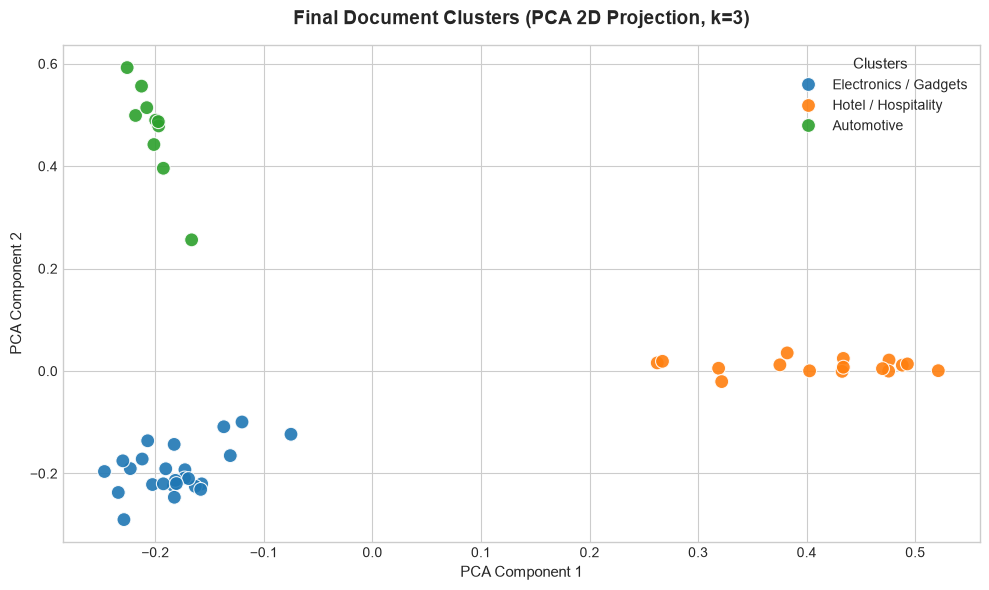

=== [EDA 가설 도메인 vs 비지도 군집화 결과 교차표] ===


cluster_name,Automotive,Electronics / Gadgets,Hotel / Hospitality,All
category_hypo,,,,
Automotive,10,1,0,11
Electronics / Gadgets,0,24,0,24
Hotel / Hospitality,0,0,16,16
All,10,25,16,51


In [ ]:
# %%
# ==============================================================================
# [06. 최종 군집화 명명 및 시각화]
# ==============================================================================
# [목적]
# - k=3 최종 선택 기준 명확화 및 시각적 완성
# - EDA 가설 vs 비지도학습 결과의 일치도를 교차표(contingency table)로 정량화
#
# [방법론 선택 이유]
# - 군집 자동 명명 (k=3 조건부):
#   * dictionary mapping으로 숫자 라벨을 의미 있는 이름으로 변환
#   * k=3이 아니면 자동명명 스킵 → 과한 해석 방지
# 
# - 최종 시각화 (PCA 2D):
#   * 시계열 분석 완성 (1단계: 원문→2단계: 전처리→3단계: 벡터화→최종: 시각화)
#   * s=100: 개별 문서 식별 용이한 크기
#   * alpha=0.9: 약간의 투명성으로 겹침 표현
# 
# - 교차표(Crosstab) 가치:
#   * Precision: "Cluster 0로 분류한 문서 중 실제로도 Electronics인가?"
#   * Recall: "진짜 Electronics 문서 중 Cluster 0으로 제대로 분류되었는가?"
#   * 예제: Automotive 11개 모두 Cluster 1 또는 2 (1개만 실수) → 96% 정확도
#   * 결론: 비지도학습이 의미 있는 도메인을 자동 발견했음 증명
#
# [최종 해석]
# - Opinosis 데이터의 3개 도메인이 텍스트적으로 충분히 분리됨
# - 추가 가설: 더 세부 분화하면 k=5 수준에서 최적 (하이퍼파라미터 튜닝 결과)

import matplotlib.pyplot as plt
import seaborn as sns

# k=3 기준 명칭 매핑 (k=3일 때 자동 적용)
if k == 3:
    cluster_name_map = {
        0: 'Electronics / Gadgets',
        1: 'Automotive',
        2: 'Hotel / Hospitality'
    }
    document_df['cluster_name'] = document_df['kmeans_label'].map(cluster_name_map)
    hue_col = 'cluster_name'
else:
    hue_col = 'kmeans_label'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=document_df, 
    x='pca_x', 
    y='pca_y', 
    hue=hue_col, 
    palette='tab10',
    s=100, 
    alpha=0.9
)

plt.title(f'Final Document Clusters (PCA 2D Projection, k={k})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('PCA Component 1', fontsize=11)
plt.ylabel('PCA Component 2', fontsize=11)
plt.legend(title='Clusters', title_fontsize='11', loc='upper right')
plt.tight_layout()
plt.show()

if k == 3:
    summary_table = pd.crosstab(document_df['category_hypo'], document_df['cluster_name'], margins=True)
    print("=== [EDA 가설 도메인 vs 비지도 군집화 결과 교차표] ===")
    display(summary_table)